In [7]:
import matplotlib.pyplot as plt
import datajoint as dj
import numpy as np

from hexmaze import plot_hex_maze

import spyglass.common as sgc
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeDecodedPosition,
    HexMazeDecodedPositionHex,
    HexMazeDecodedHexPath,
    HexMazeDecodedHexPathBarrierChange,
)

# Make sure the session exists in the hex maze tables
nwb_file_name = "Toby20250316_.nwb"
restriction = {"nwb_file_name": nwb_file_name, "epoch": 5}
restriction = "nwb_file_name LIKE '%Toby%'"

display(HexMazeBlock() & restriction)

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
Toby20250310_.nwb,1,1,"10,11,15,20,31,34,38,41,44",epoch1_block1,10.0,90.0,50.0,69,probability change
Toby20250310_.nwb,1,2,"10,11,15,20,31,34,38,41,44",epoch1_block2,90.0,10.0,50.0,69,probability change
Toby20250310_.nwb,1,3,"10,11,15,20,31,34,38,41,44",epoch1_block3,10.0,50.0,90.0,69,probability change
Toby20250310_.nwb,3,1,"9,10,19,21,22,29,38,41,43",epoch3_block1,90.0,10.0,50.0,69,probability change
Toby20250310_.nwb,3,2,"9,10,19,21,22,29,38,41,43",epoch3_block2,50.0,90.0,10.0,69,probability change
Toby20250310_.nwb,3,3,"9,10,19,21,22,29,38,41,43",epoch3_block3,50.0,10.0,90.0,69,probability change
Toby20250310_.nwb,5,1,"5,11,13,19,26,30,31,34,38,46",epoch5_block1,10.0,90.0,50.0,69,probability change
Toby20250310_.nwb,5,2,"5,11,13,19,26,30,31,34,38,46",epoch5_block2,90.0,50.0,10.0,69,probability change
Toby20250310_.nwb,5,3,"5,11,13,19,26,30,31,34,38,46",epoch5_block3,10.0,50.0,90.0,69,probability change
Toby20250310_.nwb,7,1,"5,12,14,16,27,29,36,37,44",epoch7_block1,50.0,90.0,10.0,60,barrier change


In [9]:
# Functions in dev so we just copy them for now
from hexmaze import maze_to_graph, get_critical_choice_points, get_path_independent_hexes_to_port, resolve_port
import networkx as nx

def divide_into_thirds(maze) -> list[set]:
    """
    Given a maze with a single critical choice point, divide the
    open hexes in the maze into 3 sets: hexes between the choice point
    and port 1, hexes between the choice point and port 2, and hexes
    between the choice point and port 3.

    NOTE for mazes with multiple choice points, or a single choice point
    that is a part of a cycle, dividing the maze into three groups will
    result in hexes between choice points that are not included in any 
    of these groups, because they do not clearly belong to one of the 
    three groups based on maze structure alone.

    Parameters:
        maze (list, set, frozenset, np.ndarray, str, nx.Graph):
            The hex maze represented in any valid format

    Returns:
        list[set]: [{hexes between the choice point and port 1},
            {between choice and port 2}, {between choice and port 3}]
    """
    # Convert all valid maze representations to a nx.Graph object
    graph = maze_to_graph(maze)

    # Get choice point(s) for this maze
    choice_points = get_critical_choice_points(maze)

    # Remove the choice point(s) from the maze graph to split it into (hopefully 3) components
    for choice_point in choice_points:
        graph.remove_node(choice_point)

    # Get the components of the split graph (each containing a reward port)
    components = list(nx.connected_components(graph))

    # Sometimes based on loops in the maze structure, the choice point(s) don't split the maze into clear components
    # Maze '8,9,11,17,20,23,31,34,38,46' is an example of this.
    # In this case, we remove the entire cycle containing the choice point(s).
    # Re-evaluate if we encounter a maze where this is not the best way to deal with this.
    has_single_cp_cycle = (len(components) < 3)
    if has_single_cp_cycle:
        maze_graph = maze_to_graph(maze)
        cycle_basis = nx.cycle_basis(maze_graph)
        # Remove all hexes that are part of cycles that include a choice point
        hexes_to_remove = {
            h
            for cycle in cycle_basis
            if any(cp in cycle for cp in choice_points)
            for h in cycle
        }
        maze_graph.remove_nodes_from(hexes_to_remove)
        components = list(nx.connected_components(maze_graph))

    # Find each component containing hex 1, hex 2, and hex 3 (in that order)
    thirds = []
    for hex in [1, 2, 3]:
        for maze_component in components:
            if hex in maze_component:
                thirds.append(set(maze_component))
                break

    # Any unclassified, non-choice-point hex that is path-independent to a port belongs in that port's third
    # See maze '8,9,11,17,20,23,31,34,38,46' as an example: this addition 
    # adds hex 30 to port 2's third and hex 40 to port 3's third.
    if has_single_cp_cycle:
        all_third_hexes = thirds[0] | thirds[1] | thirds[2]
        for port in [1, 2, 3]:
            for h in get_path_independent_hexes_to_port(maze, port):
                if h not in all_third_hexes and h not in choice_points:
                    thirds[port - 1].add(h)

    return thirds


def classify_hexes_by_region(maze) -> dict[str, set[int]]:
    """
    Classify open hexes in a maze into regions based on the critical choice
    points. Each hex is assigned to one of:
        - 'to_1', 'to_2', 'to_3': hexes between a port and its choice point
        - 'loop_12', 'loop_13', 'loop_23': hexes on the choice loop between
            two port-specific choice points
        - 'choice_point_1', 'choice_point_2', 'choice_point_3': the choice
            points themselves

    For mazes with no choice loops, loop sets will be empty.

    Parameters:
        maze (list, set, frozenset, np.ndarray, str, nx.Graph):
            The hex maze represented in any valid format

    Returns:
        dict[str, set[int]]: Dictionary mapping region names to sets of hexes
    """
    graph = maze_to_graph(maze)

    # Get port-specific choice points
    cp = {}
    all_cps = set()
    for port in [1, 2, 3]:
        cp[port] = get_critical_choice_points(maze, start_port=port)
        all_cps.update(cp[port])

    # Remove all choice points and find connected components
    subgraph = graph.copy()
    subgraph.remove_nodes_from(all_cps)
    components = list(nx.connected_components(subgraph))

    regions = {
        "to_1": set(), "to_2": set(), "to_3": set(),
        "loop_12": set(), "loop_13": set(), "loop_23": set(),
        "choice_point_1": cp[1], "choice_point_2": cp[2], "choice_point_3": cp[3],
    }
    
    # TODO: for cases where there are multiple choice points from a given port,
    # how we should define the loop hexes is a little unclear.
    # See maze '8,10,15,25,27,34,37,40,45' as an example of this.

    # Simple case: removing choice points cleanly splits into 3+ components
    # (one per port, plus any loop segments between choice points)
    if len(components) >= 3:
        for component in components:
            for port in [1, 2, 3]:
                if port in component:
                    regions[f"to_{port}"].update(component)
                    break
            else:
                # Loop segment: check which choice points it's adjacent to
                adjacent_ports = set()
                for h in component:
                    for neighbor in graph.neighbors(h):
                        for port in [1, 2, 3]:
                            if neighbor in cp[port]:
                                adjacent_ports.add(port)
                pair = tuple(sorted(adjacent_ports))
                if len(pair) == 2:
                    regions[f"loop_{pair[0]}{pair[1]}"].update(component)

        return regions

    # Edge case: a choice point is on a cycle, so removing choice points
    # doesn't split into 3 components. Use divide_into_thirds (which now
    # absorbs effective choice points) to get the thirds.
    thirds = divide_into_thirds(maze)
    for port, third_hexes in zip([1, 2, 3], thirds):
        regions[f"to_{port}"].update(third_hexes)

    # Remaining unclassified hexes are the loop interior
    all_classified = regions["to_1"] | regions["to_2"] | regions["to_3"] | all_cps
    loop_hexes = set(graph.nodes) - all_classified

    # Classify loop hexes by which pair of thirds they're adjacent to
    for component in nx.connected_components(graph.subgraph(loop_hexes)):
        adjacent_ports = set()
        for h in component:
            for neighbor in graph.neighbors(h):
                for port in [1, 2, 3]:
                    if neighbor in regions[f"to_{port}"]:
                        adjacent_ports.add(port)
        pair = tuple(sorted(adjacent_ports))
        if len(pair) == 2:
            regions[f"loop_{pair[0]}{pair[1]}"].update(component)

    return regions


def divide_into_thirds_from_port(maze, start_port) -> list[set]:
    """
    Like divide_into_thirds, but resolves choice loop ambiguity from the
    perspective of a given start port. Loop segments between the start port's
    choice point and another port's choice point are assigned to that other
    port's third. Loop segments between the other two ports remain unassigned.

    For mazes with no choice loops, this is equivalent to divide_into_thirds.

    Parameters:
        maze (list, set, frozenset, np.ndarray, str, nx.Graph):
            The hex maze represented in any valid format
        start_port (int or str): The starting reward port (1/2/3 or A/B/C)

    Returns:
        list[set]: [{hexes in port 1's third}, {port 2's third}, {port 3's third}]
    """
    start_port = resolve_port(start_port)
    other_ports = [p for p in [1, 2, 3] if p != start_port]
    regions = classify_hexes_by_region(maze)

    thirds = [set(), set(), set()]
    for port in [1, 2, 3]:
        thirds[port - 1].update(regions[f"to_{port}"])
        # Other ports' choice points belong to their third, but the
        # start port's choice point is left unclassified (like divide_into_thirds)
        if port != start_port:
            thirds[port - 1].update(regions[f"choice_point_{port}"])

    # Loop segments touching the start port get assigned to the other port
    for other in other_ports:
        pair = tuple(sorted([start_port, other]))
        thirds[other - 1].update(regions[f"loop_{pair[0]}{pair[1]}"])

    # loop between the two non-start ports is left unassigned

    return thirds

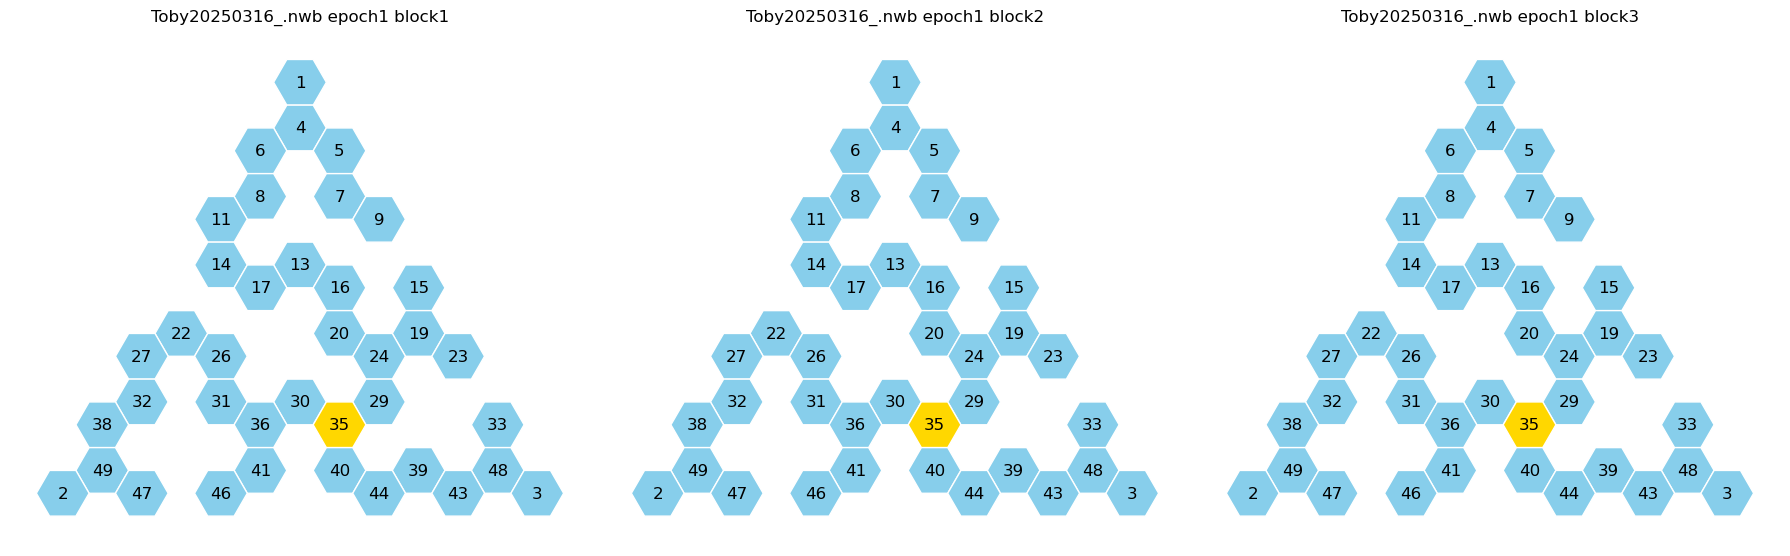

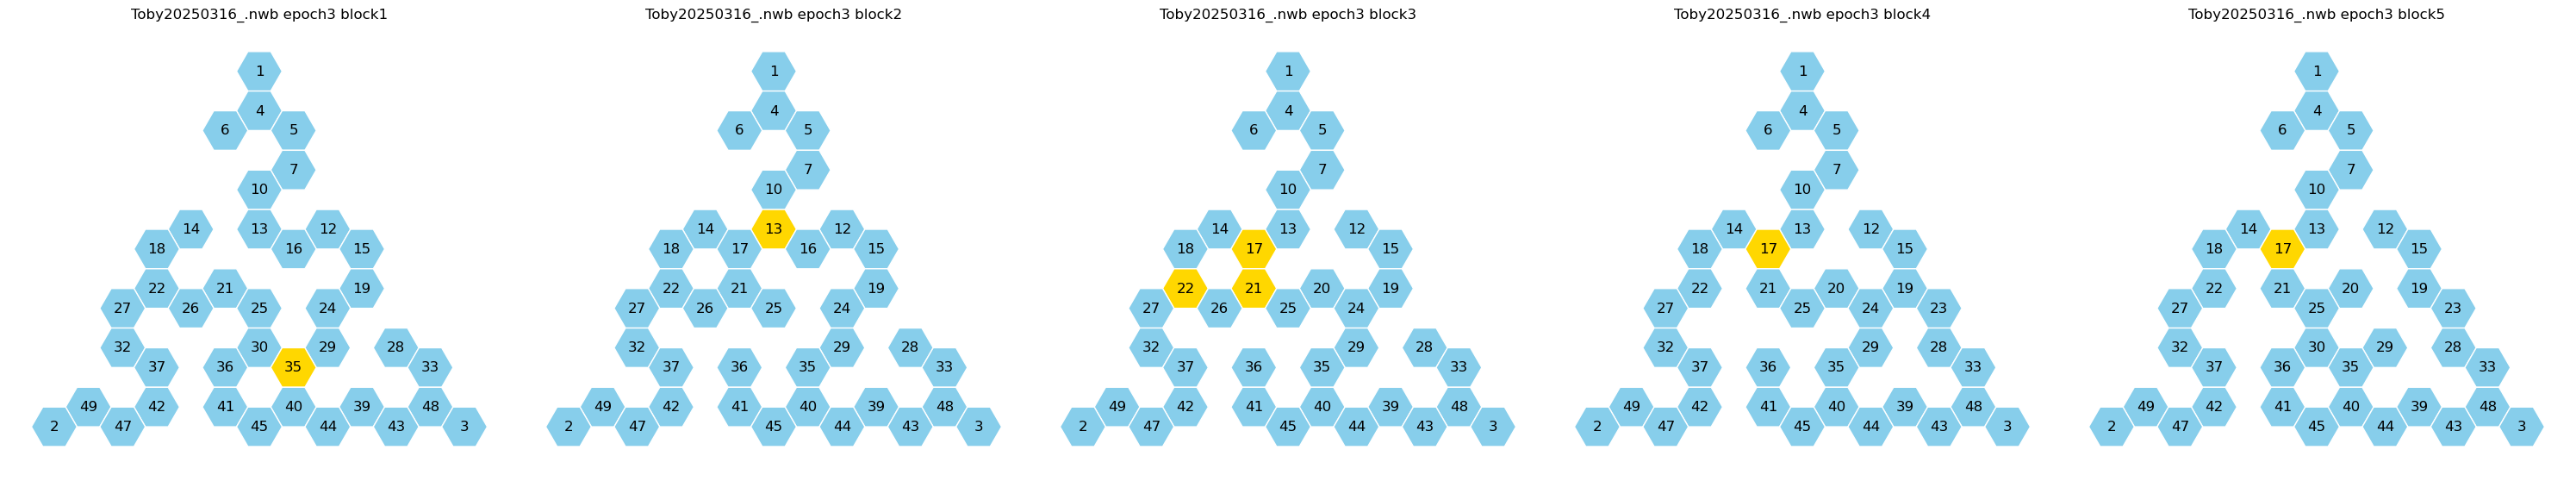

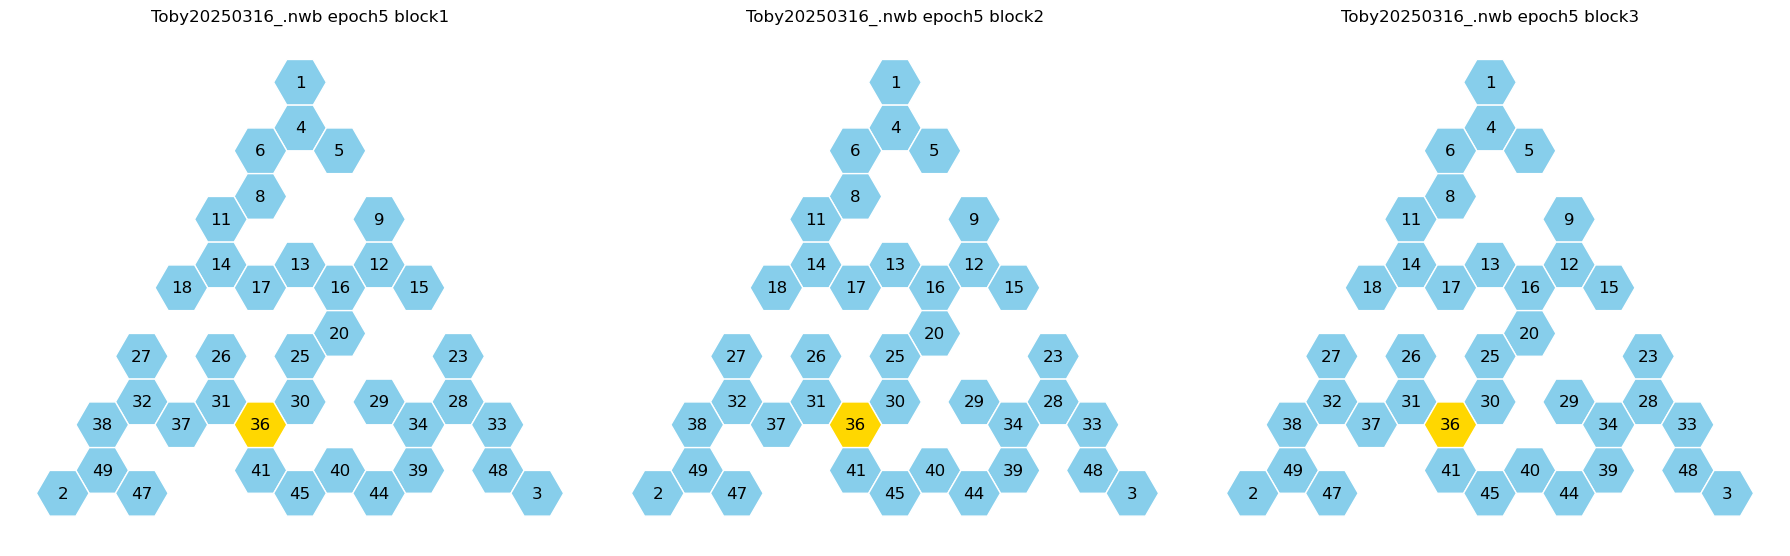

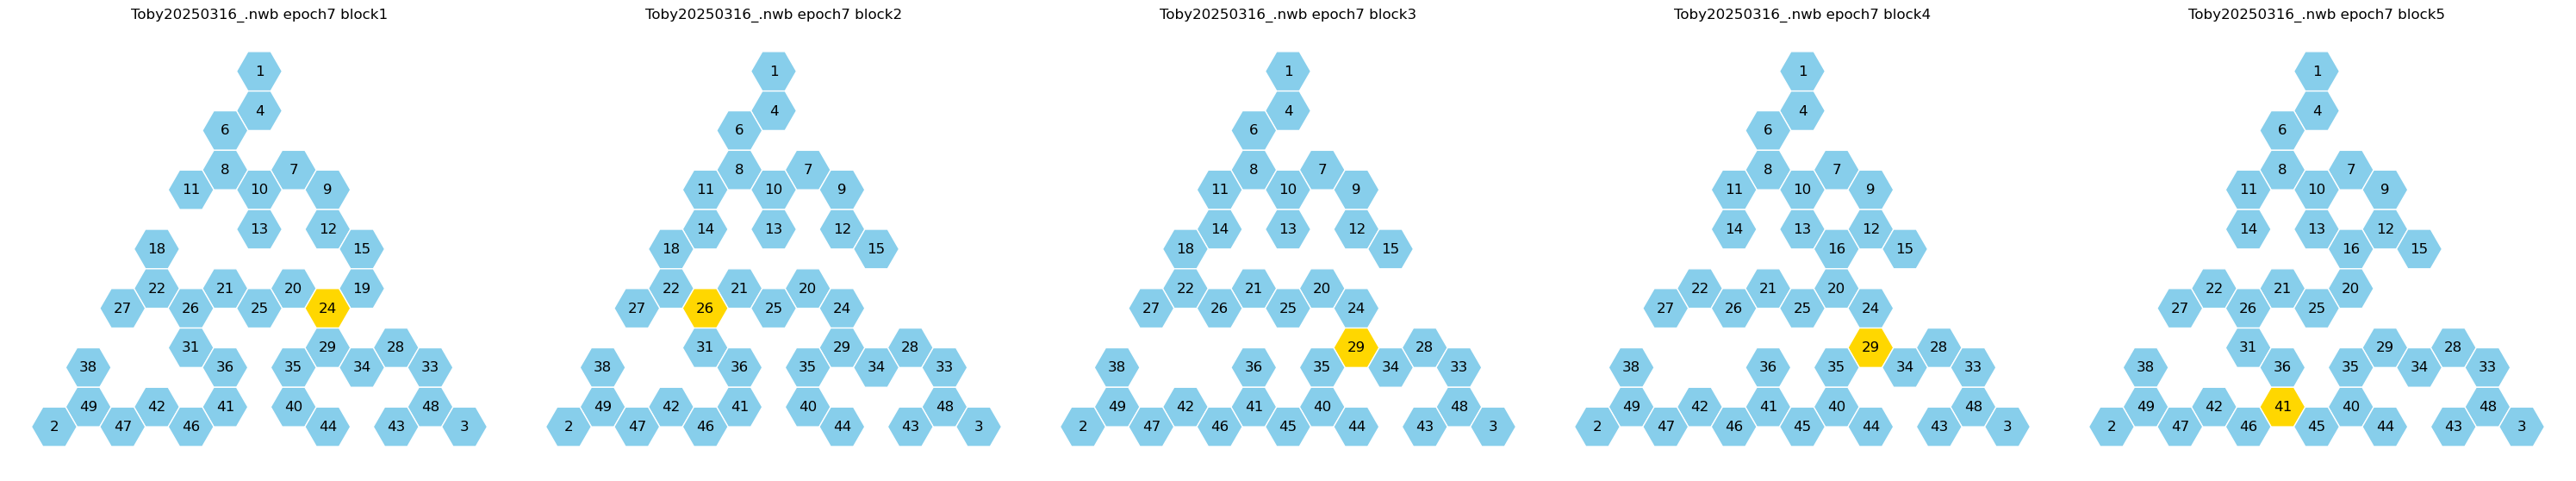

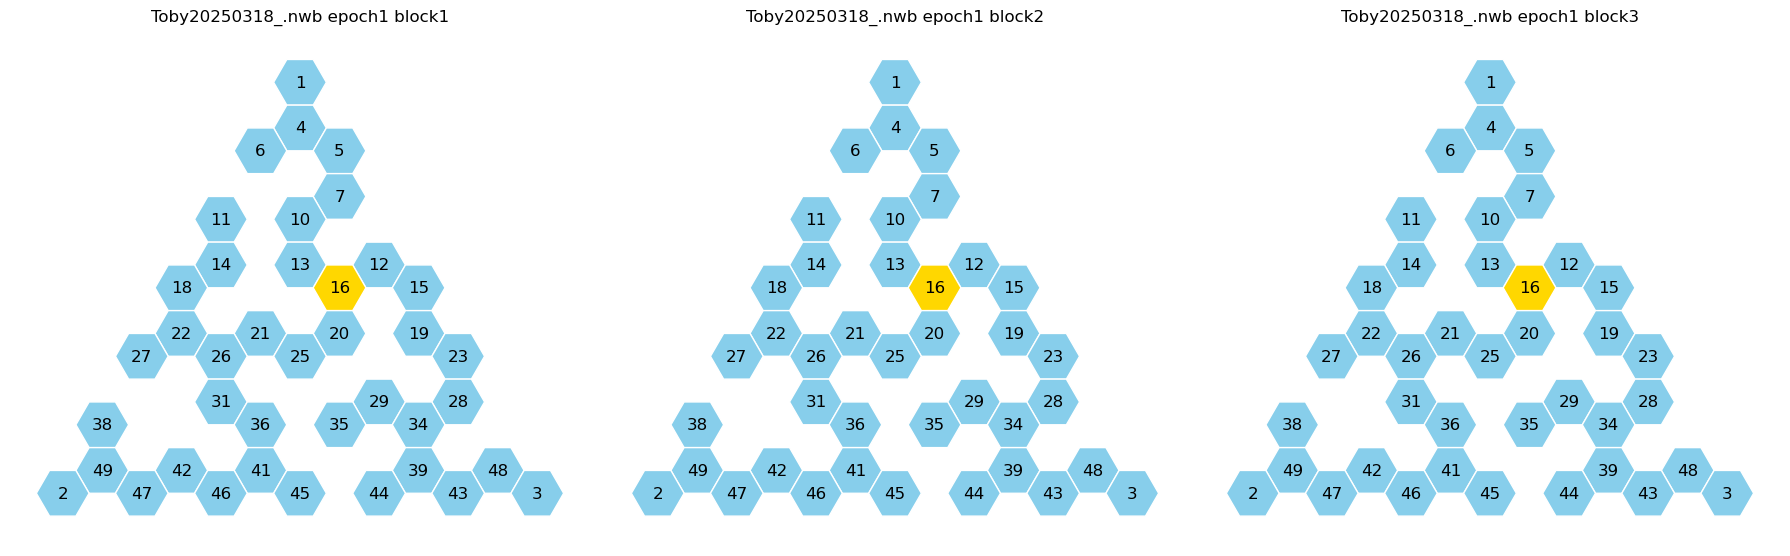

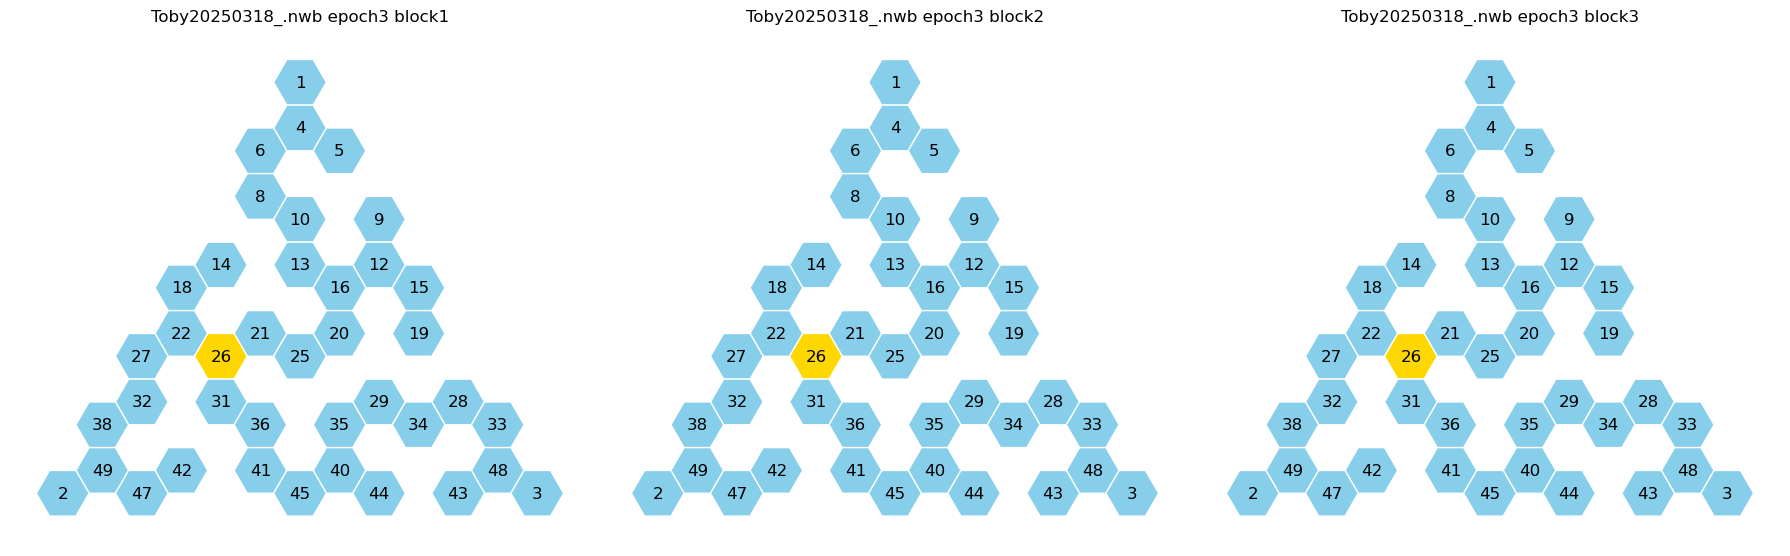

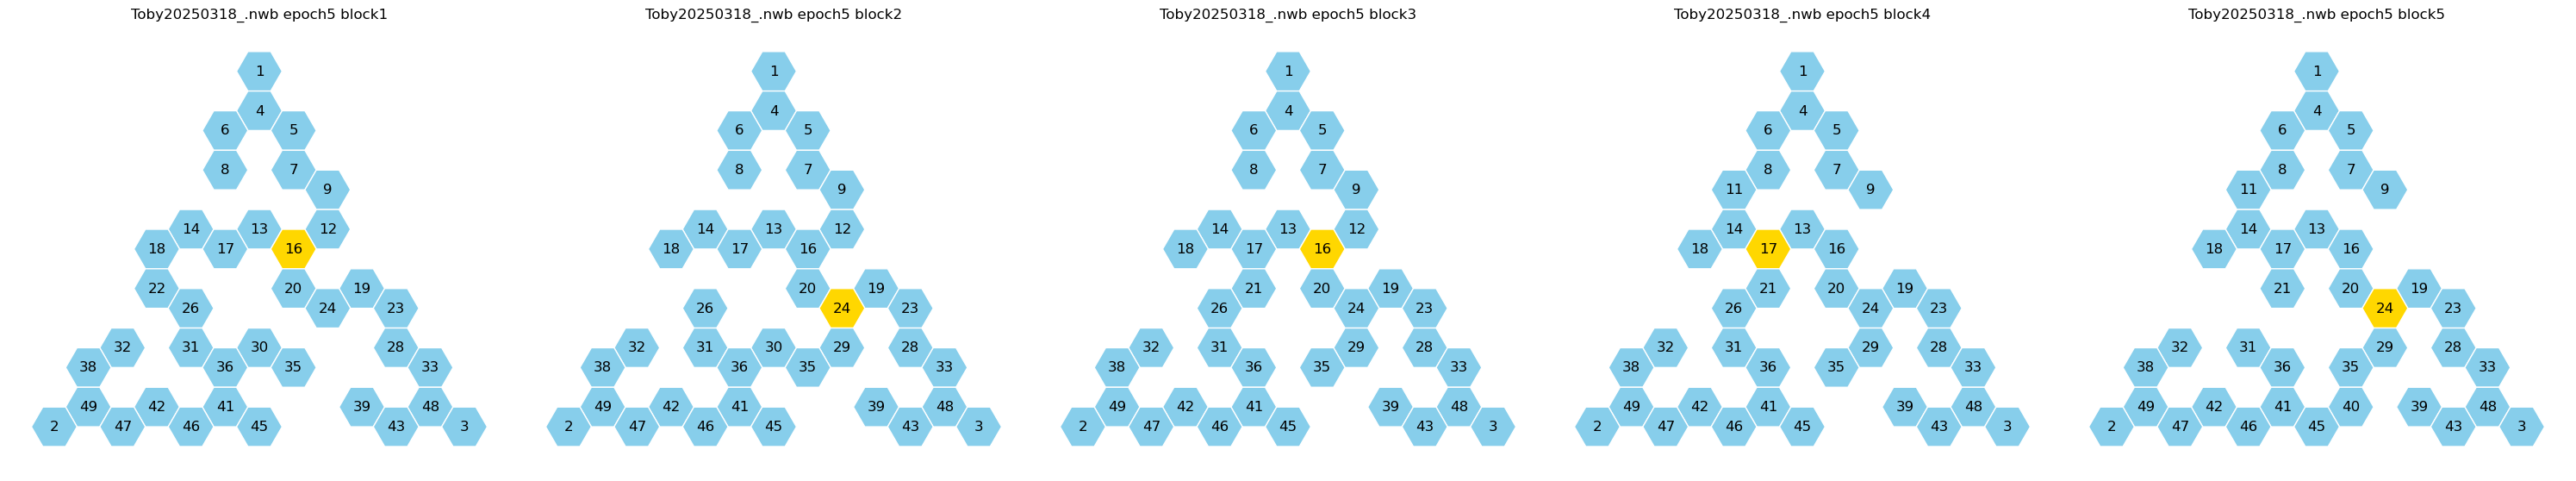

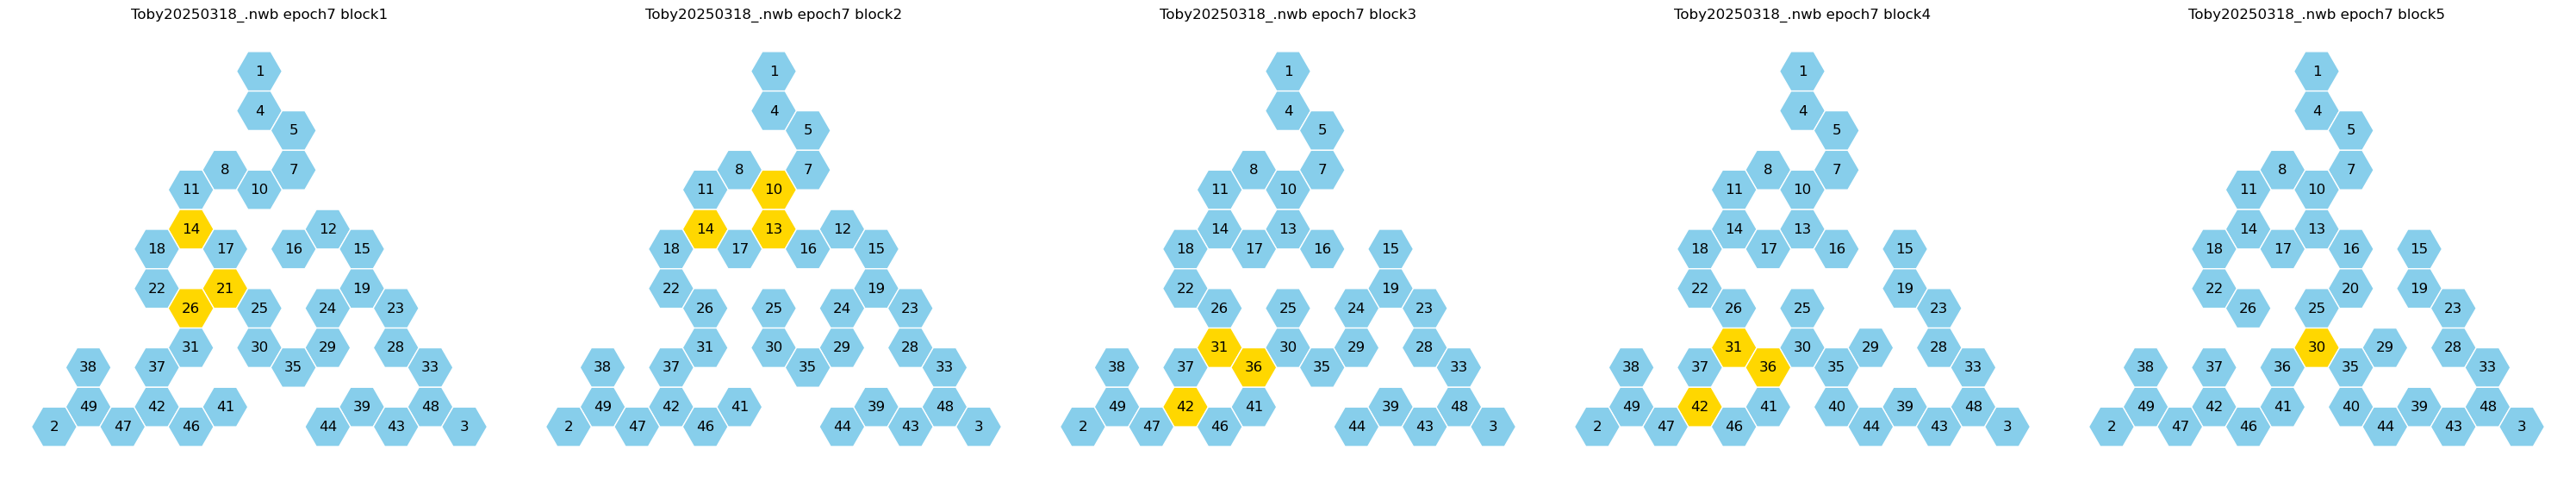

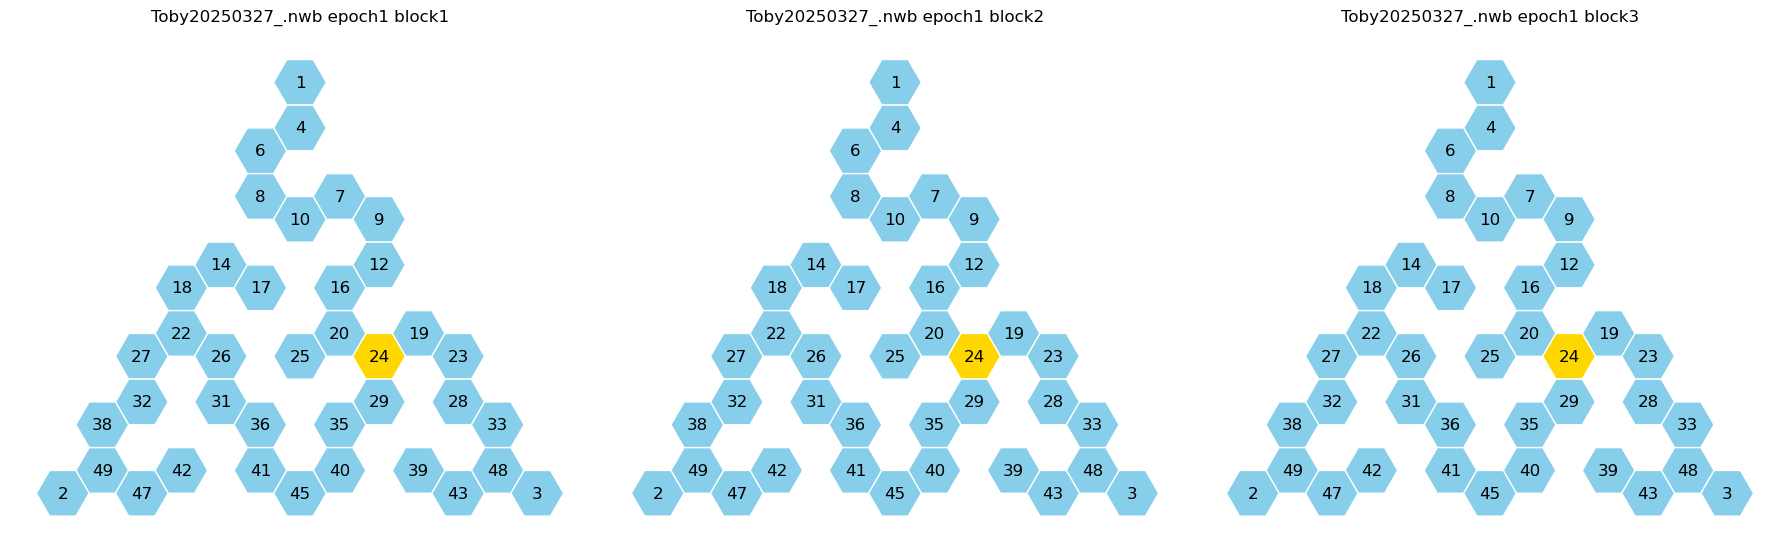

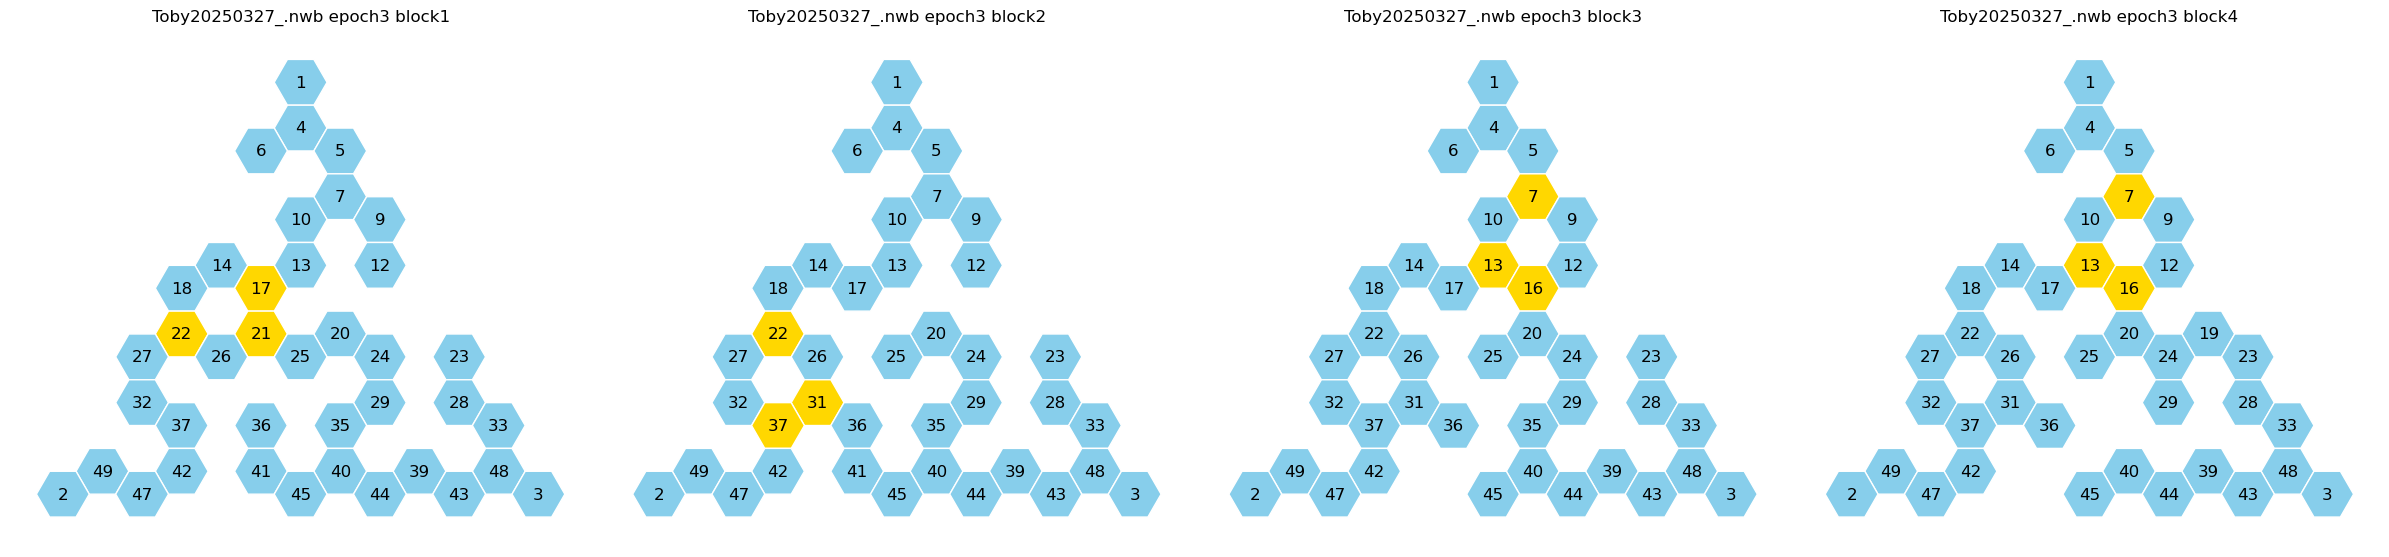

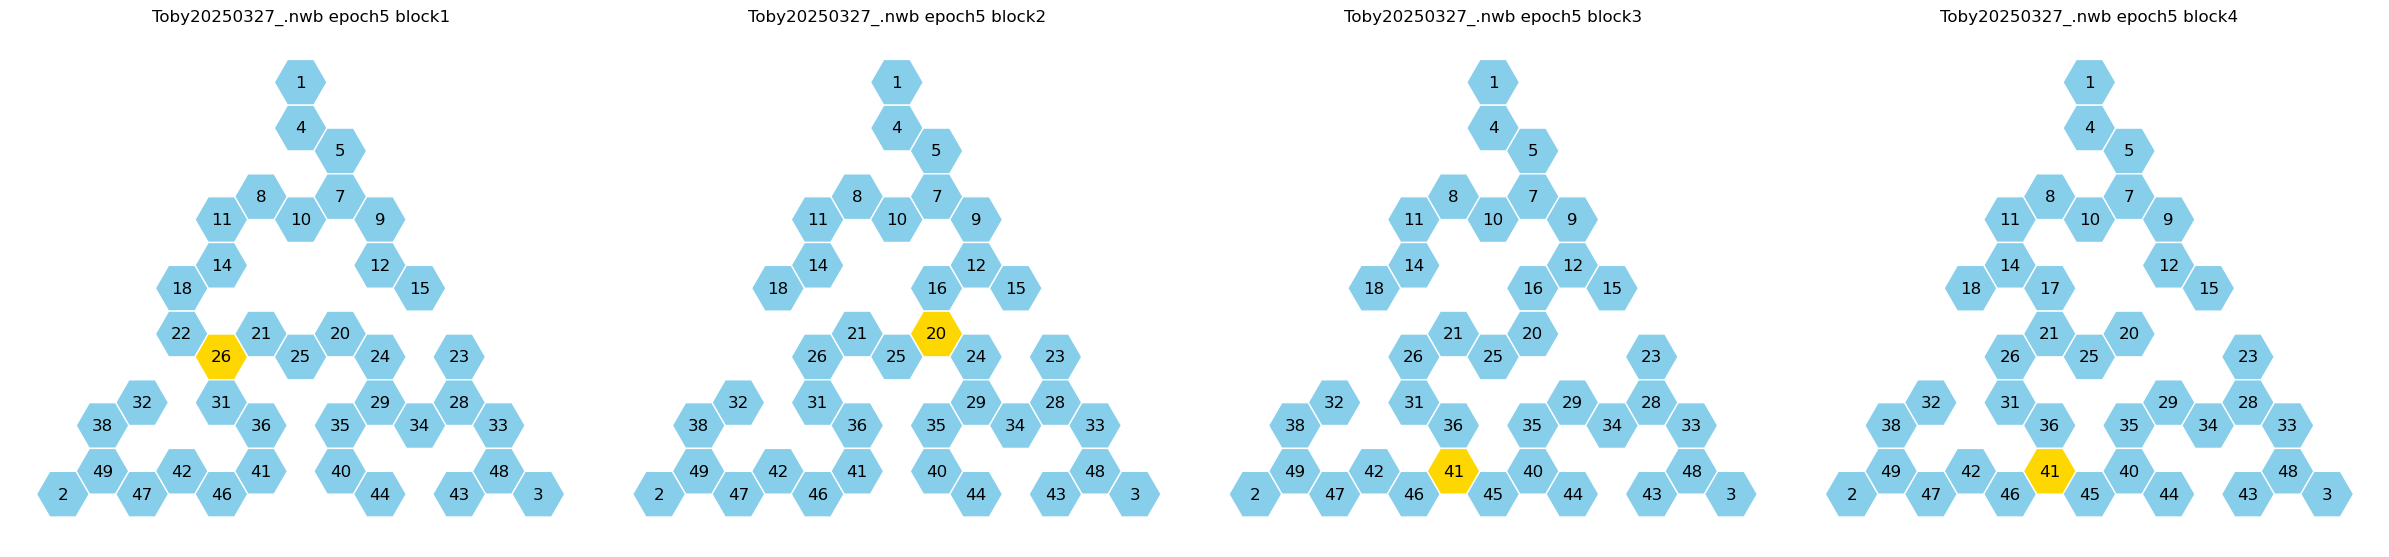

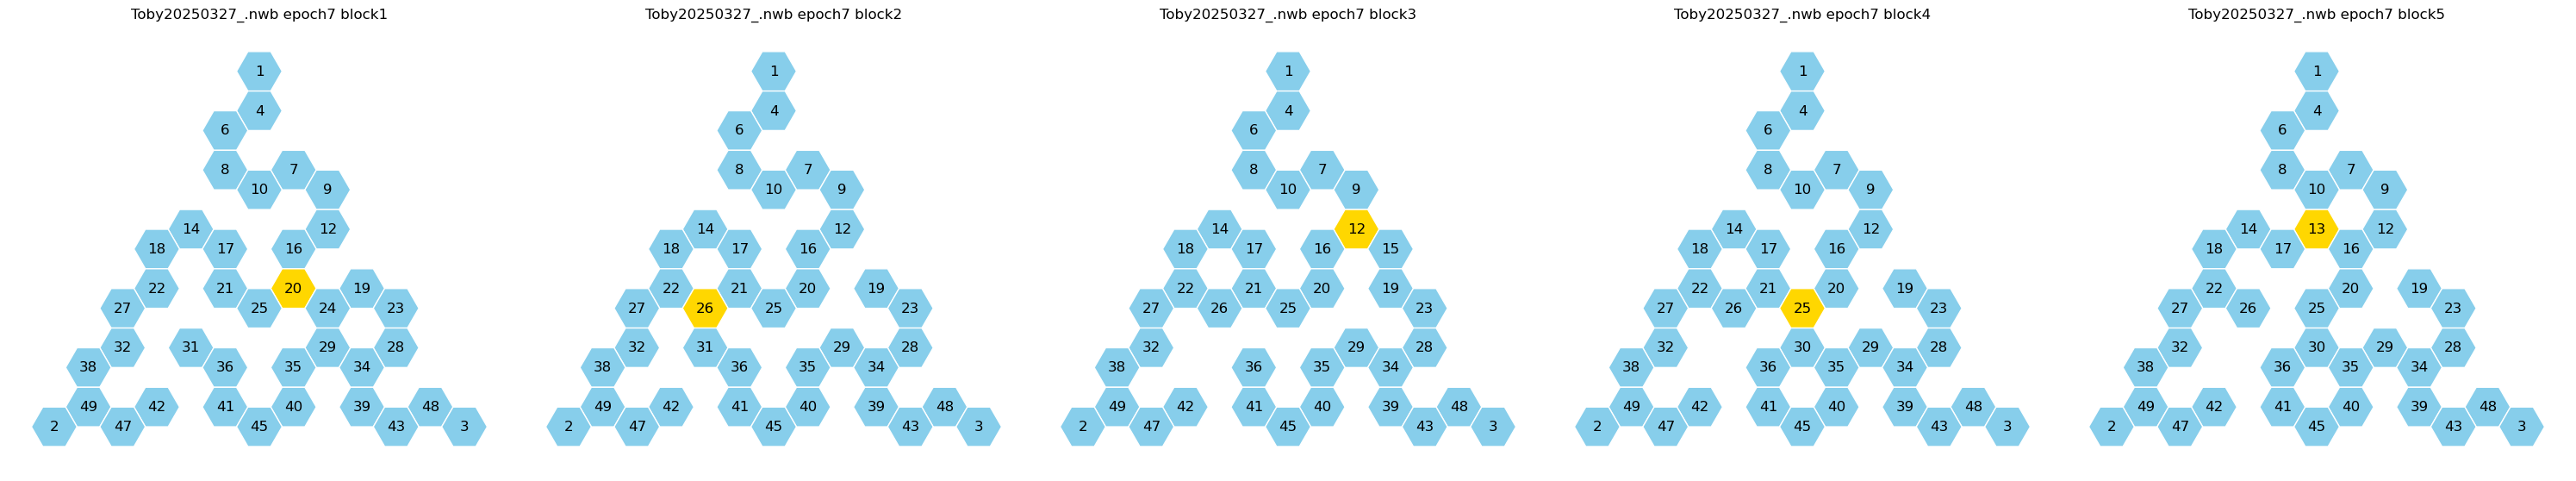

In [8]:
# Get all unique nwb/epoch combinations in HexMazeDecodedPositionHex
keys = (HexMazeDecodedPositionHex & restriction).fetch("nwb_file_name", "epoch", as_dict=True)
unique_keys = list({(k["nwb_file_name"], k["epoch"]) for k in keys})

for nwb_file, epoch in sorted(unique_keys):
    # Get all blocks (each with a config_id/maze) for this nwb/epoch
    blocks = (HexMazeBlock & {"nwb_file_name": nwb_file, "epoch": epoch}).fetch(
        "block", "config_id", as_dict=True
    )

    fig, axes = plt.subplots(1, len(blocks), figsize=(6 * len(blocks), 6))
    if len(blocks) == 1:
        axes = [axes]

    for ax, block in zip(axes, blocks):
        plot_hex_maze(
            barriers=block["config_id"],
            ax=ax,
            show_choice_points=True,
            show_barriers=False,
        )
        ax.set_title(f"{nwb_file} epoch{epoch} block{block['block']}")

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1670881/2719275756.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trial_means = df.groupby("epoch_trial_num").apply(


Text(0, 0.5, 'Decode hex distance (duration-weighted)')

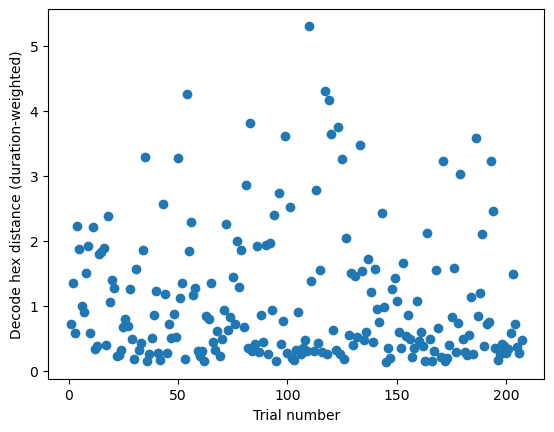

In [42]:
df = (HexMazeDecodedHexPath & key).fetch1_dataframe()

trial_means = df.groupby("epoch_trial_num").apply(
    lambda g: np.average(g["decode_hex_distance"], weights=g["duration"])
)

fig, ax = plt.subplots()
ax.scatter(trial_means.index, trial_means.values, marker="o")
ax.set_xlabel("Trial number")
ax.set_ylabel("Decode hex distance (duration-weighted)")


/tmp/ipykernel_1670881/4192333347.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trial_by_dist = df.groupby(["epoch_trial_num", col]).apply(
/tmp/ipykernel_1670881/4192333347.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trial_by_dist = df.groupby(["epoch_trial_num", col]).apply(
/tmp/ipykernel_1670881/4192333347.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior

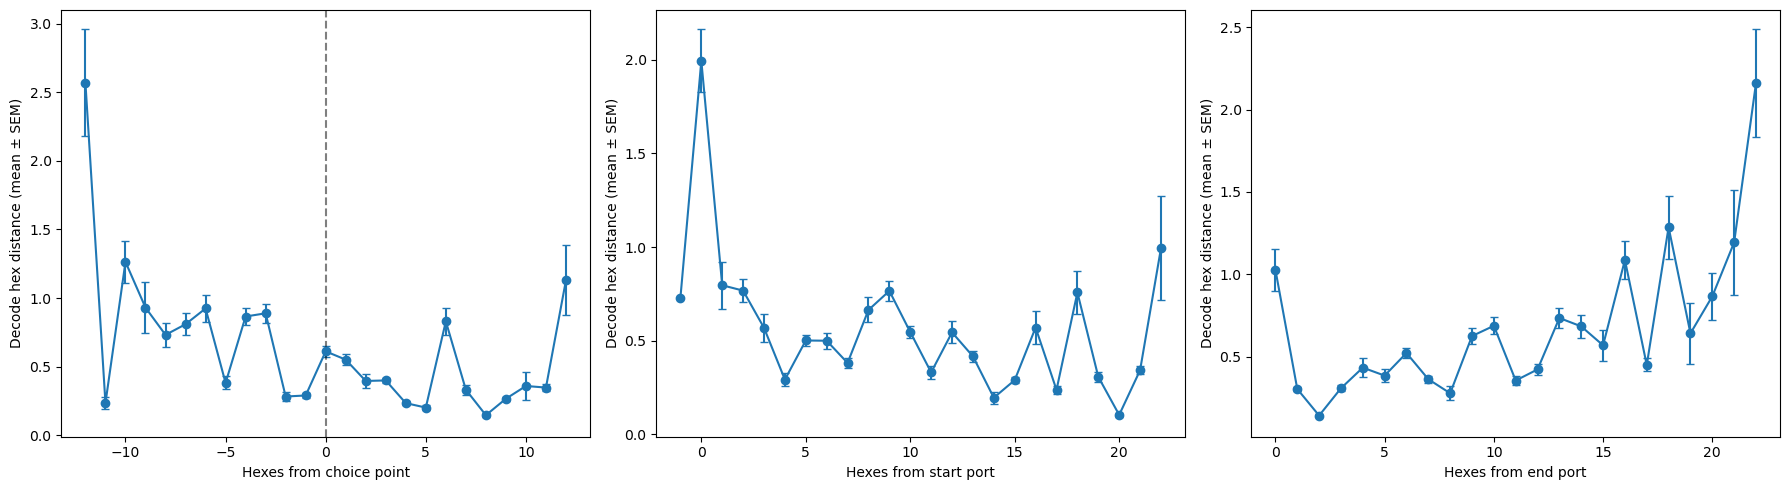

In [43]:
# Fetch df
df = (HexMazeDecodedHexPath & key).fetch1_dataframe()

# For each (trial, hexes_from_choice/start/end), get duration-weighted decode distance
# Then average across trials at each distance from choice
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label in zip(axes, 
    ["hexes_from_choice", "hexes_from_start", "hexes_from_end"],
    ["choice point", "start port", "end port"]):
    
    trial_by_dist = df.groupby(["epoch_trial_num", col]).apply(
        lambda g: np.average(g["decode_hex_distance"], weights=g["duration"])
    ).reset_index(name="decode_dist")
    
    mean_by_dist = trial_by_dist.groupby(col)["decode_dist"].agg(["mean", "sem"])
    
    ax.errorbar(mean_by_dist.index, mean_by_dist["mean"], yerr=mean_by_dist["sem"], marker="o", capsize=3)
    ax.set_xlabel(f"Hexes from {label}")
    ax.set_ylabel("Decode hex distance (mean ± SEM)")
    if col == "hexes_from_choice":
        ax.axvline(0, color="k", linestyle="--", alpha=0.5)

plt.tight_layout()


/tmp/ipykernel_1670881/3922707925.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_error = df.groupby("hexes_from_choice").apply(


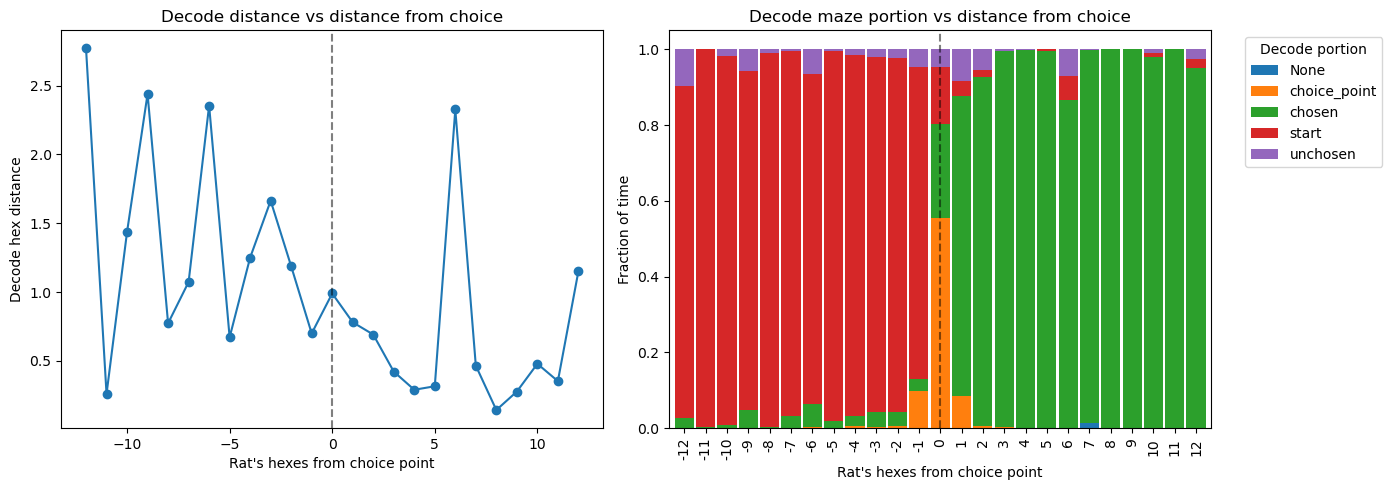

In [44]:
# Fetch df
df = (HexMazeDecodedHexPath & key).fetch1_dataframe()

# Duration-weighted decode distance by distance from choice point
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weighted_error = df.groupby("hexes_from_choice").apply(
    lambda g: np.average(g["decode_hex_distance"], weights=g["duration"])
)
weighted_error.plot(ax=axes[0], marker="o")
axes[0].axvline(0, color="k", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Rat's hexes from choice point")
axes[0].set_ylabel("Decode hex distance")
axes[0].set_title("Decode distance vs distance from choice")

# Duration-weighted decode maze portion
dur_by_portion = df.groupby(["hexes_from_choice", "decode_maze_portion"])["duration"].sum().unstack(fill_value=0)
proportions = dur_by_portion.div(dur_by_portion.sum(axis=1), axis=0)
proportions.plot.bar(ax=axes[1], stacked=True, width=0.9)
axes[1].axvline(proportions.index.get_loc(0) if 0 in proportions.index else 0,
                color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Rat's hexes from choice point")
axes[1].set_ylabel("Fraction of time")
axes[1].set_title("Decode maze portion vs distance from choice")
axes[1].legend(title="Decode portion", bbox_to_anchor=(1.05, 1))

plt.tight_layout()


/tmp/ipykernel_1670881/313027562.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trial_by_dist = df.groupby(["epoch_trial_num", "hexes_from_choice"]).apply(


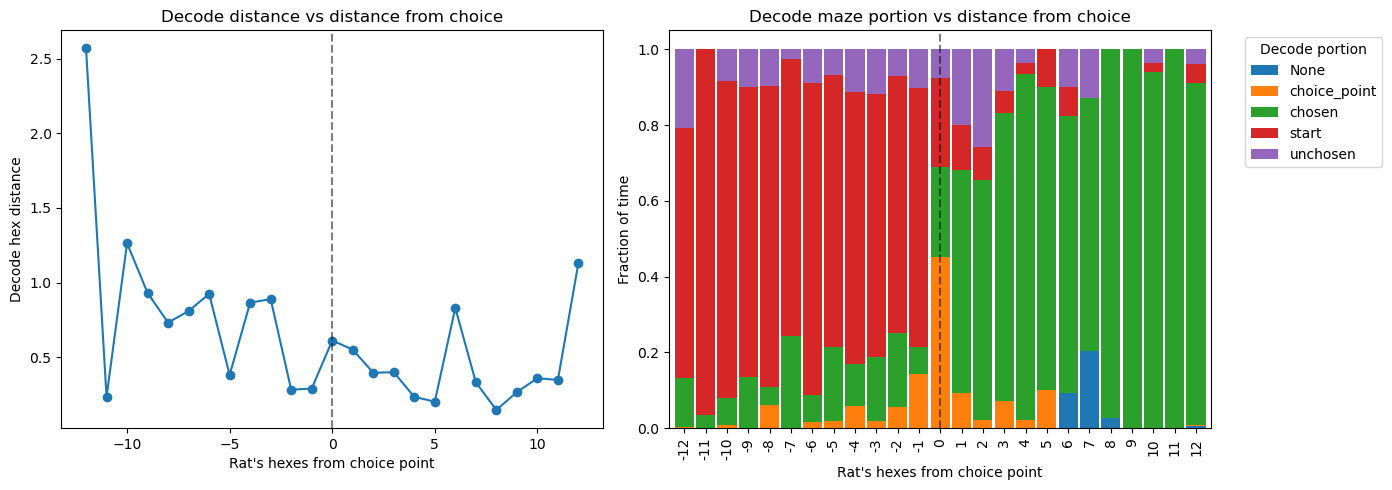

In [45]:
# Fetch df
df = (HexMazeDecodedHexPath & key).fetch1_dataframe()

# Duration-weighted decode distance by distance from choice point
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean of per-trial duration-weighted averages at each distance from choice
trial_by_dist = df.groupby(["epoch_trial_num", "hexes_from_choice"]).apply(
    lambda g: np.average(g["decode_hex_distance"], weights=g["duration"])
).reset_index(name="decode_dist")
mean_by_dist = trial_by_dist.groupby("hexes_from_choice")["decode_dist"].mean()
mean_by_dist.plot(ax=axes[0], marker="o")
axes[0].axvline(0, color="k", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Rat's hexes from choice point")
axes[0].set_ylabel("Decode hex distance")
axes[0].set_title("Decode distance vs distance from choice")

# Duration-weighted decode maze portion (mean of per-trial proportions)
# Duration-weighted decode maze portion (mean of per-trial proportions, renormalized)
trial_portions = df.groupby(["epoch_trial_num", "hexes_from_choice", "decode_maze_portion"])["duration"].sum()
trial_totals = df.groupby(["epoch_trial_num", "hexes_from_choice"])["duration"].sum()
trial_props = (trial_portions / trial_totals).rename("prop").reset_index()
mean_props = trial_props.groupby(["hexes_from_choice", "decode_maze_portion"])["prop"].mean().unstack(fill_value=0)
mean_props = mean_props.div(mean_props.sum(axis=1), axis=0)  # renormalize to sum to 1
mean_props.plot.bar(ax=axes[1], stacked=True, width=0.9)
axes[1].axvline(mean_props.index.get_loc(0) if 0 in mean_props.index else 0,
                color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Rat's hexes from choice point")
axes[1].set_ylabel("Fraction of time")
axes[1].set_title("Decode maze portion vs distance from choice")
axes[1].legend(title="Decode portion", bbox_to_anchor=(1.05, 1))

plt.tight_layout()


/tmp/ipykernel_1670881/2298142093.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trial_by_section = df.groupby(["epoch_trial_num", "maze_portion"]).apply(


<Axes: title={'center': 'Decode distance by maze section'}, xlabel='maze_portion', ylabel='Decode hex distance (mean ± SEM)'>

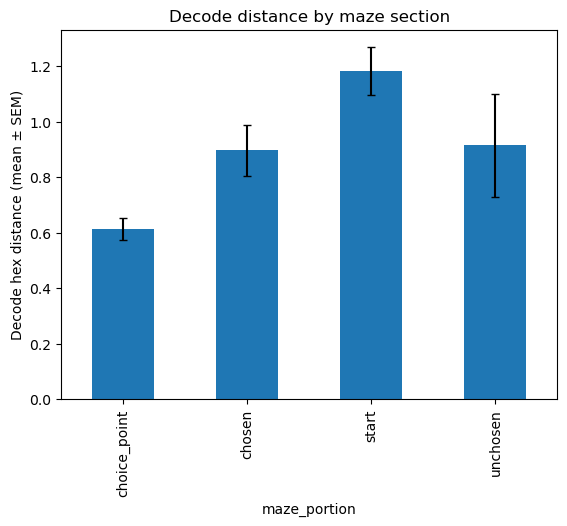

In [46]:
# Duration-weighted decode distance by maze section (mean of per-trial averages)
trial_by_section = df.groupby(["epoch_trial_num", "maze_portion"]).apply(
    lambda g: np.average(g["decode_hex_distance"], weights=g["duration"])
).reset_index(name="decode_dist")

mean_by_section = trial_by_section.groupby("maze_portion")["decode_dist"].agg(["mean", "sem"])
mean_by_section["mean"].plot.bar(yerr=mean_by_section["sem"], capsize=3,
    ylabel="Decode hex distance (mean ± SEM)", title="Decode distance by maze section")



<Axes: title={'center': 'Where does the decoder represent?'}, xlabel='maze_portion', ylabel='Proportion of decode time'>

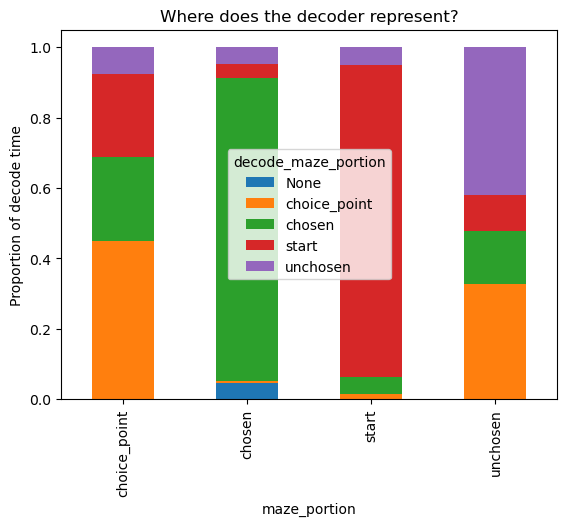

In [47]:
# Where does the decode represent? Duration-weighted, mean of per-trial proportions
trial_portions = df.groupby(["epoch_trial_num", "maze_portion", "decode_maze_portion"])["duration"].sum()
trial_totals = df.groupby(["epoch_trial_num", "maze_portion"])["duration"].sum()
trial_props = (trial_portions / trial_totals).rename("prop").reset_index()
mean_props = trial_props.groupby(["maze_portion", "decode_maze_portion"])["prop"].mean().unstack(fill_value=0)
mean_props = mean_props.div(mean_props.sum(axis=1), axis=0)  # renormalize
mean_props.plot.bar(stacked=True, ylabel="Proportion of decode time",
                    title="Where does the decoder represent?")



/tmp/ipykernel_1670881/3442790130.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unchosen_by_trial = df.groupby("epoch_trial_num").apply(


<Axes: xlabel='Trial', ylabel='Fraction decode in unchosen arm'>

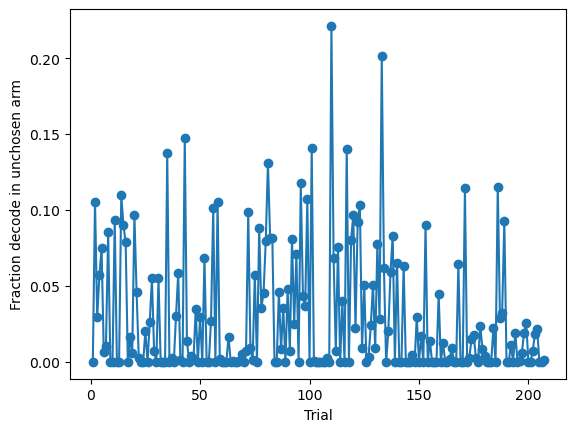

In [48]:
# Fraction of time decode is in unchosen arm, per trial (duration-weighted)
unchosen_by_trial = df.groupby("epoch_trial_num").apply(
    lambda g: np.average(g["decode_maze_portion"] == "unchosen", weights=g["duration"])
)
unchosen_by_trial.plot(marker="o", xlabel="Trial", ylabel="Fraction decode in unchosen arm")



<Axes: title={'center': 'Decode location when rat is at choice point'}, xlabel='decode_maze_portion', ylabel='Fraction of time'>

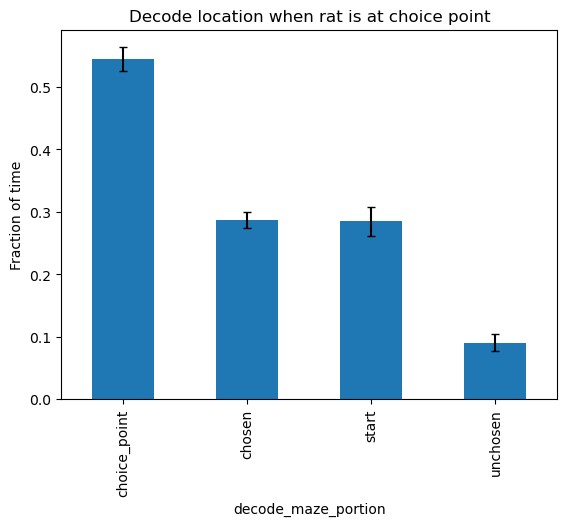

In [49]:
# When the animal is at a choice point, where does decode point?
cp_df = df[df["maze_portion"] == "choice_point"]
trial_portions = cp_df.groupby(["epoch_trial_num", "decode_maze_portion"])["duration"].sum()
trial_totals = cp_df.groupby("epoch_trial_num")["duration"].sum()
trial_props = (trial_portions / trial_totals).rename("prop").reset_index()
mean_props = trial_props.groupby("decode_maze_portion")["prop"].agg(["mean", "sem"])
mean_props["mean"].plot.bar(yerr=mean_props["sem"], capsize=3,
    ylabel="Fraction of time", title="Decode location when rat is at choice point")

